---
format:
  html:
    code-fold: true
execute:
  echo: true
---

[← Back to article notes](../index.qmd)

# Implementation notebook

- Title: Subspace clustering in high-dimensions: Phase transitions & Statistical-to-Computational gap
- Authors: Pesce, Loureiro, Krzakala, Zdeborová
- Year:    2022

In [52]:
#| code-summary: "Import Libraries"
import torch
import sklearn
import numpy
from matplotlib import pyplot as plt
from torch.func import vmap, jacrev
import numpy as np

# Generative model

We suppose that the dimension of the space is $d=4000$ and that the number of clusters is $k=3$. Let $\alpha=2$ the ratio between the number of total data points and the dimension. In other words $n\approx\alpha\cdot d=8000$.

Let $\rho$ the density of the active elements, the sparsity is described by $s\approx\rho\cdot d$. Here, we will use $\rho=0.05$ and $s=200$

$\lambda$ is the SNR that describes the separability of the clusters.

In [53]:
#| code-summary: "Setup of the model"
d = 1000
k = 2   # number of clusters
alpha = 2.0
rho = 0.18
lam = 25  # lambda
n = int(alpha*d)
s = int(rho*d)

threshold = lam * (alpha)**0.5 / k
print(f"{threshold=}")

threshold=17.67766952966369


In [54]:
#| code-summary: "Generative model"

class Generator:
    def __init__(self, n, k, d, rho):
        # make balanced labels
        labels = torch.randint(0,k,(n,))
        # make the matrix U
        U = torch.zeros(n, k)
        U[torch.arange(n), labels] = 1
        U = U - 1/k
        # make a vector with d bernoulli samples
        samples = torch.rand(d) < rho
        # only where samples is True the matrix has values like N(0,1)
        V = torch.zeros(d,k)
        nz = int(torch.sum(samples).item())
        V[samples] = torch.randn(nz,k)
        W = torch.randn(d,n)
        X = (lam / s)**0.5*V@(U.T) + W
        
        self.__X = X
        self.__W = W
        self.__V = V
        self.__U = U
        self.__labels = labels
    
    def get_values(self):
        return self.__X
    
    @property
    def W(self):
        return self.__W
    
    @property
    def V(self):
        return self.__V
    
    @property
    def U(self):
        return self.__U
    
    @property
    def labels(self):
        return self.__labels

In [55]:
#| code-summary: "Generate values"
myGen = Generator(n,k,d,rho)
X = myGen.get_values()
print(X.shape)

torch.Size([1000, 2000])


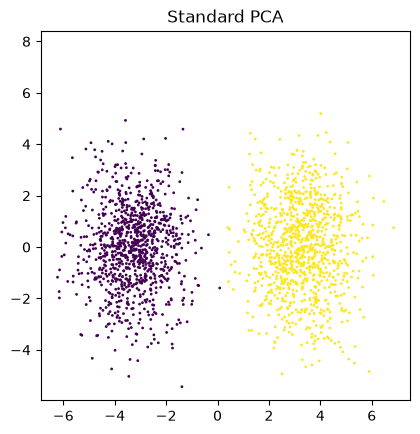

In [56]:
#| code-summary: "PCA clustering"

np_X = X.numpy()
pca_object = sklearn.decomposition.PCA(n_components=k,)
red_np_X = pca_object.fit_transform(np_X.T)

# plot
plt.scatter(red_np_X[:,0], red_np_X[:,1], c=myGen.labels.numpy(), alpha=1, s=1)
plt.axis('square')
plt.title("Standard PCA")
plt.show()

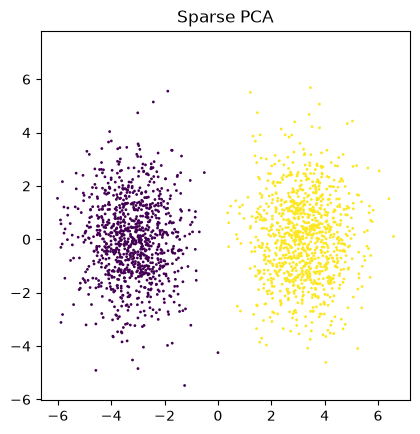

In [57]:
#| code-summary: "sparse PCA clustering"
spca = sklearn.decomposition.SparsePCA(n_components=2, alpha=1.0)
red_np_X = spca.fit_transform(np_X.T)

# plot
plt.scatter(red_np_X[:,0], red_np_X[:,1], c=myGen.labels.numpy(), alpha=1, s=1)
plt.axis('square')
plt.title("Sparse PCA")
plt.show()

In [64]:
def compute_jacobian(func, x):
    # func image shape (batch, n1, ..., nm)
    # x shape (batch, k)
    # J shape (batch, n1, ..., nm, k)
    J = vmap(jacrev(func), randomness='same')(x)
    return J

def denoising_func_u(A,B):
    # A: size (k,k)
    # B: size (n,k)
    flag = False
    if B.ndim == 1:
        flag = True
        B = B.reshape(1,-1)
    U = torch.eye(k) - 1/k  # shape (k,k)
    exp_argument = B @ U - 0.5 * torch.einsum('ni,ij,nj->n',U,A,U)[None,:]
    exp_argument = exp_argument - exp_argument.max(dim=1, keepdim=True)[0]
    exp = torch.exp(exp_argument)  # shape (n,k)
    w_exp = exp @ U  # shape (n,k)
    sol = w_exp / torch.sum(exp, dim=-1, keepdim=True)  # shape (n,k)
    if flag:
        sol = sol.reshape(-1)
    return sol

def denoising_func_v(A,B):
    # A: size (k,k)
    # B: size (d,k)
    flag = False
    if B.ndim == 1:
        B = B.reshape(1,-1)
        flag = True
    IpA = torch.eye(k) + A
    invIpA = torch.linalg.inv(IpA)  # shape (k,k)
    invIpAb = torch.einsum('pk,dk->dp', invIpA, B)
    binvIpAb = torch.einsum('dp,dp->d',B, invIpAb)
    ret = (rho * invIpAb) / (rho + (1-rho)*(IpA.det())**0.5*torch.exp(-binvIpAb*0.5))[:,None]
    if flag:
        ret = ret.reshape(-1)
    return ret

def algorithm_2(X, std, tmax):
    # size (d,n)
    U_prev = torch.zeros(n,k)
    V_prev = torch.zeros(d,k)
    U = torch.randn(n,k)*std  # nxk
    V = torch.randn(d,k)*std  # dxk
    A_u = torch.empty(k,k)    # kxk
    A_v = torch.empty(k,k)    # kxk
    B_u = torch.empty(n,k)    # nxk
    B_v = torch.empty(d,k)    # dxk
    sigma_u = torch.zeros(n,k,k)  # nxkxk
    sigma_v = torch.zeros(d,k,k)  # dxkxk
    
    for _ in range(tmax):
        A_u = lam / s * (U.T @ U)   # kxk
        A_v = lam / s * (V.T @ V)   # kxk   
        B_v = (lam / s)**0.5 * X @ U - lam / s * torch.einsum('pq,jqk->pk', V_prev, sigma_u)
        B_u = (lam / s)**0.5 * X.T @ V - lam / s * torch.einsum('pq,jqk->pk', U_prev, sigma_v)
        V_prev = V.clone()
        U_prev = U.clone()
        V = denoising_func_v(A_v,B_v)
        U = denoising_func_u(A_u,B_u)
        sigma_v = compute_jacobian(lambda B: denoising_func_v(A_v,B), B_v)
        sigma_u = compute_jacobian(lambda B: denoising_func_u(A_u,B), B_u)

    return V, U, sigma_v, sigma_u

Vapp, Uapp, sigma_v, sigma_u = algorithm_2(X, 0.01, 100)

Xapp = (lam / s)**0.5 * Vapp @ Uapp.T


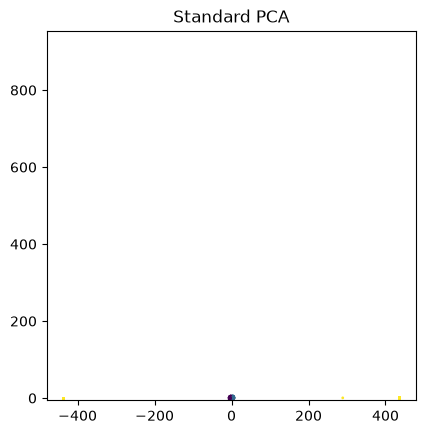

In [65]:
Xappfit = pca_object.transform(Xapp.T)

# plot
mixed = np.concatenate((red_np_X, Xappfit))
labels = myGen.labels.numpy()
labels = np.concatenate((labels,np.ones(Xappfit.shape[0])*(k+1)))
plt.scatter(mixed[:,0], mixed[:,1], c=labels, alpha=1, s=1)
plt.axis('square')
plt.title("Standard PCA")
plt.show()